# Comparison using likelihood of ACT, PLANCK and DESI DR2 between:
- $\Lambda CDM$ model
- $w_0 w_a CDM$ model
- Quintessence (Exponential Potential)

In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import camb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


GetDist Version: 1.5.4, Matplotlib version: 3.9.2


### Loading samples

In [2]:
# Loading samples
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_planck_desidr2', 'act_planck_desidr2')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_planck_desidr2', 'act_planck_desidr2')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_planck_desidr2', '1_EXP_lcdm_act_planck_desidr2')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)


/home/andrewcats/tesi_magistrale/lcdm/act_planck_desidr2/act_planck_desidr2.1.txt
/home/andrewcats/tesi_magistrale/lcdm/act_planck_desidr2/act_planck_desidr2.2.txt
/home/andrewcats/tesi_magistrale/lcdm/act_planck_desidr2/act_planck_desidr2.3.txt
/home/andrewcats/tesi_magistrale/lcdm/act_planck_desidr2/act_planck_desidr2.4.txt
Removed 0.3 as burn in
['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'A_act', 'P_act', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'A_planck', 'chi2__BAO', 'chi2__CMB', 'chi2', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut', 'chi2__act_dr6_cmbonly', 'chi2__bao.desi_dr2.desi_bao_all']
/home/andrewcats/tesi_magistrale/w0wacdm/act_planck_desidr2/act_planck_desidr2.1.txt
/home/andrewcats/tesi_magistrale/w0wacdm/act_planck_desidr2/act_planck_desidr2.2.txt
/home/andrewcats/tesi_magistral

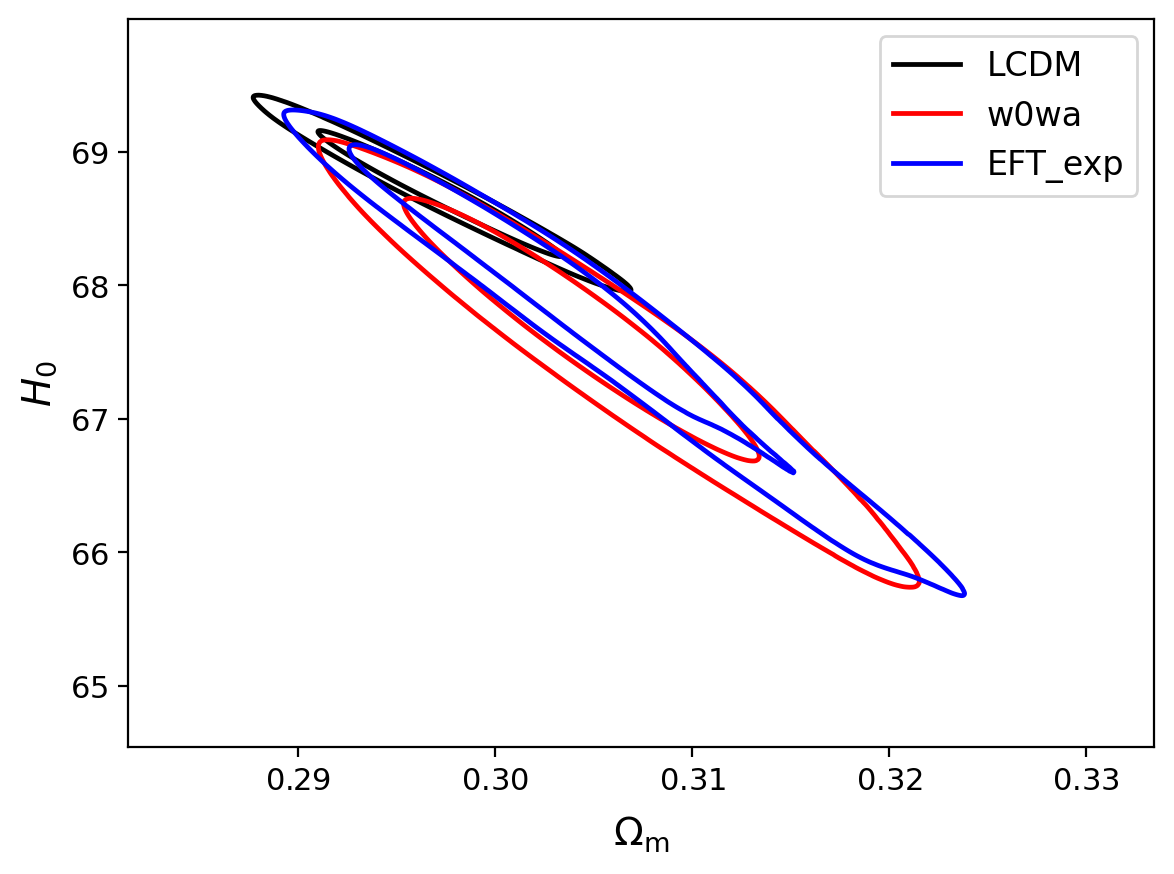

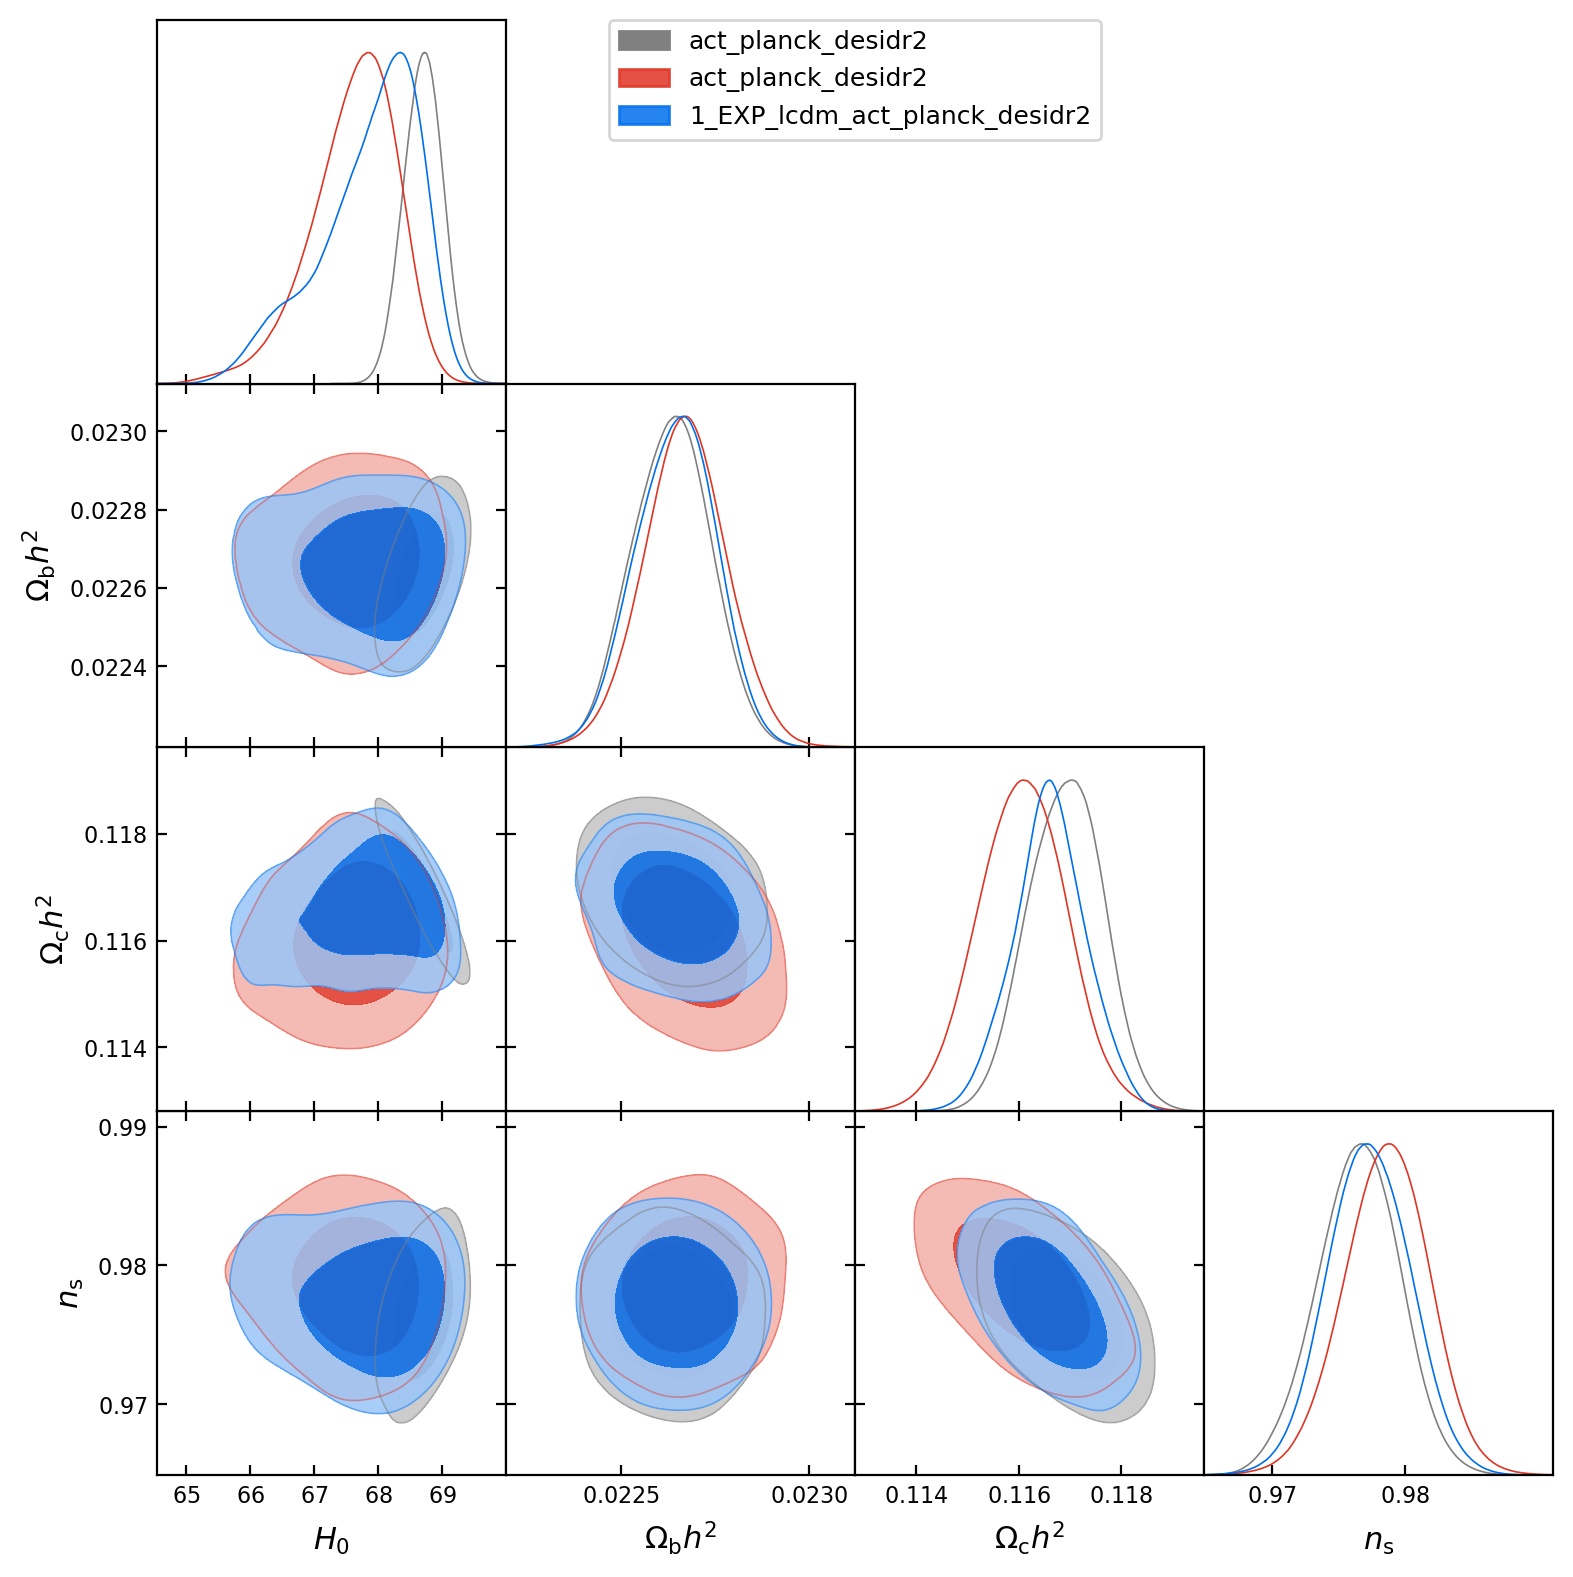

In [ ]:

# Comparing 3 samples in the same plot
# lcdm vs w0wa vs exp
samples = [samples_lcdm, samples_w0wa, samples_exp]
g = plots.get_single_plotter()
g.plot_2d(samples, ['omegam', 'H0'])
g.add_legend(['LCDM', 'w0wa', 'EFT_exp'])

g1 = plots.get_subplot_plotter()
g1.triangle_plot(samples, ['H0', 'ombh2', 'omch2', 'ns'], filled=True)
g1.add_legend(['LCDM', 'w0wa', 'EFT_exp'])

### Comparison with BIC and AIC method

In [ ]:
# Comparing models using BIC (Bayesian Information Criterion)
# BIC = -2*ln(L) + k*ln(n) where L = likelihood, k = number of parameters, n = number of data points
# Load chain data without headers

data_raw = np.loadtxt(os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_planck_desidr2', 'act_planck_desidr2.1.txt'))

# Add number of extra columns at the end (you know them already)
# Let's assume the last 13 columns are weights + diagnostics like chi2, etc.
n_params = len(samples_w0wa.paramNames.names)
#print(n_params) #result is 36
n_total_cols = data_raw.shape[1]
n_extra_cols = n_total_cols - n_params

# Extract those column names
extra_cols = ["weight", "chi2__BAO", "chi2__CMB", "chi2__SN", "minuslogprior",
              "minuslogprior__0", "chi2", "chi2__sn.desy5", "chi2__bao.desi_dr2.desi_bao_all",
              "chi2__planck_2018_lowl.TT", "chi2__planck_2018_lowl.EE_sroll2",
              "chi2__act_dr6_cmbonly.PlanckActCut"]

# Create DataFrame
all_col_names = param_names_w0wa + extra_cols[:n_extra_cols]
df = pd.DataFrame(data_raw, columns=all_col_names)

# Compute loglike and logposterior
df["loglike"] = -0.5 * df["chi2"]
#df["logprior"] = -df["minuslogprior"]
#df["logpost"] = df["loglike"] + df["logprior"]

# Compute stats
max_loglike_w0wa = df["loglike"].max()
mean_loglike_w0wa = df["loglike"].mean()
complexity_w0wa = 2 * (mean_loglike_w0wa - max_loglike_w0wa)

print(f"Max loglike: {max_loglike_w0wa:.3f}")
print(f"Mean loglike: {mean_loglike_w0wa:.3f}")
print(f"Bayesian complexity (effective params): {complexity_w0wa:.3f}")
print(f"Number of samples: {len(df)}")

k_w0wa = len(samples_w0wa.paramNames.names)  # number of params
print(k_w0wa) # 36 --> N.B: maybe this is not the number of parameters, but the number of columns in the data frame
n_w0wa = len(df)                             # number of data points (or samples?)

aic_w0wa = 2 * k_w0wa - 2 * max_loglike_w0wa
bic_w0wa = k_w0wa * np.log(n_w0wa) - 2 * max_loglike_w0wa

print(f"AIC: {aic_w0wa:.2f}")
print(f"BIC: {bic_w0wa:.2f}")
